1. Find which users are adopted users
    1. For each user in `takehome_user_engagement`, check whether there are any 7 day periods where the user logged in on 3 separate days
2. Add to `takehome_users` a column `adopted` indicating whether the user is an adopted user
3. EDA `takehome_users`
4. Model for feature importance

In [1]:
import pandas as pd

# Load the engagement data
df_logs = pd.read_csv('takehome_user_engagement.csv', parse_dates=['time_stamp'])

# Sort by user and time
df_logs = df_logs.sort_values(['user_id', 'time_stamp'])
df_logs

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1
...,...,...,...
207912,2013-09-06 06:14:15,11996,1
207913,2013-01-15 18:28:37,11997,1
207914,2014-04-27 12:45:16,11998,1
207915,2012-06-02 11:55:59,11999,1


In [2]:
# Keep only one entry per day per user if multiple logins exist
df_logs['date'] = df_logs['time_stamp'].dt.normalize()
df_logs = df_logs.drop_duplicates(subset=['user_id', 'date'])
df_logs

,time_stamp,user_id,visited,date
0,2014-04-22 03:53:30,1,1,2014-04-22
1,2013-11-15 03:45:04,2,1,2013-11-15
2,2013-11-29 03:45:04,2,1,2013-11-29
3,2013-12-09 03:45:04,2,1,2013-12-09
4,2013-12-25 03:45:04,2,1,2013-12-25
...,...,...,...,...
207912,2013-09-06 06:14:15,11996,1,2013-09-06
207913,2013-01-15 18:28:37,11997,1,2013-01-15
207914,2014-04-27 12:45:16,11998,1,2014-04-27
207915,2012-06-02 11:55:59,11999,1,2012-06-02


In [3]:
def check_adopted(user_df):
    """Checks if a user logged in on 3 separate days within a 7-day period."""
    # Rolling 7-day window including the current row
    return user_df.rolling('7D', on='time_stamp')['date'].count().max() >= 3

# Group by user and identify adopted users
adopted = df_logs.groupby('user_id').apply(check_adopted)

print(f'Total users in logs: {df_logs["user_id"].nunique()}')
print(f'Number of adopted users identified: {adopted.sum()}')
adopted

Total users in logs: 8823
Number of adopted users identified: 1602


/tmp/ipykernel_1130/1606105045.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adopted = df_logs.groupby('user_id').apply(check_adopted)


,0
user_id,
1,False
2,True
3,False
4,False
5,False
...,...
11996,False
11997,False
11998,False


In [4]:
# Load users data (using ISO-8859-1 encoding common for this dataset)
df_users = pd.read_csv('takehome_users.csv', encoding='ISO-8859-1')

# Map the 'adopted' series to the users dataframe based on object_id
df_users['adopted'] = df_users['object_id'].map(adopted).fillna(False)

# Check the distribution of adopted users
print(df_users['adopted'].value_counts())
df_users

adopted
False    10398
True      1602
Name: count, dtype: int64


/tmp/ipykernel_1130/54670967.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_users['adopted'] = df_users['object_id'].map(adopted).fillna(False)


,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,False
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,True
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,False
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,False
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,False
...,...,...,...,...,...,...,...,...,...,...,...
11995,11996,2013-09-06 06:14:15,Meier Sophia,SophiaMeier@gustr.com,ORG_INVITE,1.378448e+09,0,0,89,8263.0,False
11996,11997,2013-01-10 18:28:37,Fisher Amelie,AmelieFisher@gmail.com,SIGNUP_GOOGLE_AUTH,1.358275e+09,0,0,200,NaN,False
11997,11998,2014-04-27 12:45:16,Haynes Jake,JakeHaynes@cuvox.de,GUEST_INVITE,1.398603e+09,1,1,83,8074.0,False
11998,11999,2012-05-31 11:55:59,Faber Annett,mhaerzxp@iuxiw.com,PERSONAL_PROJECTS,1.338638e+09,0,0,6,NaN,False


In [5]:
df_users.describe(include="all")

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
count,12000.00000,12000,12000,12000,12000,8.823000e+03,12000.000000,12000.000000,12000.000000,6417.000000,12000
unique,NaN,11996,11355,11980,5,NaN,NaN,NaN,NaN,NaN,2
top,NaN,2014-02-11 17:57:53,Cavalcanti Victor,NicolaiSHolm@yahoo.com,ORG_INVITE,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,2,5,2,4254,NaN,NaN,NaN,NaN,NaN,10398
mean,6000.50000,NaN,NaN,NaN,NaN,1.379279e+09,0.249500,0.149333,141.884583,5962.957145,NaN
std,3464.24595,NaN,NaN,NaN,NaN,1.953116e+07,0.432742,0.356432,124.056723,3383.761968,NaN
min,1.00000,NaN,NaN,NaN,NaN,1.338452e+09,0.000000,0.000000,0.000000,3.000000,NaN
25%,3000.75000,NaN,NaN,NaN,NaN,1.363195e+09,0.000000,0.000000,29.000000,3058.000000,NaN
50%,6000.50000,NaN,NaN,NaN,NaN,1.382888e+09,0.000000,0.000000,108.000000,5954.000000,NaN
75%,9000.25000,NaN,NaN,NaN,NaN,1.398443e+09,0.000000,0.000000,238.250000,8817.000000,NaN


In [6]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
 10  adopted                     12000 non-null  bool   
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 949.3+ KB


In [7]:
# Convert IDs to objects (strings)
df_users['object_id'] = df_users['object_id'].astype(str)
df_users['org_id'] = df_users['org_id'].astype(str)
# Use Int64 to handle NaNs while removing decimals, then convert to string
df_users['invited_by_user_id'] = df_users['invited_by_user_id'].astype('Int64').astype(str)

# Convert time columns to datetime
df_users['creation_time'] = pd.to_datetime(df_users['creation_time'])
df_users['last_session_creation_time'] = pd.to_datetime(df_users['last_session_creation_time'], unit='s')

# Convert flags to booleans
df_users['opted_in_to_mailing_list'] = df_users['opted_in_to_mailing_list'].astype(bool)
df_users['enabled_for_marketing_drip'] = df_users['enabled_for_marketing_drip'].astype(bool)

# Verify changes
print(df_users.dtypes)
df_users

object_id                             object
creation_time                 datetime64[ns]
name                                  object
email                                 object
creation_source                       object
last_session_creation_time    datetime64[ns]
opted_in_to_mailing_list                bool
enabled_for_marketing_drip              bool
org_id                                object
invited_by_user_id                    object
adopted                                 bool
dtype: object


,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,2014-04-22 03:53:30,True,False,11,10803,False
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,2014-03-31 03:45:04,False,False,1,316,True
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,2013-03-19 23:14:52,False,False,94,1525,False
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,2013-05-22 08:09:28,False,False,1,5151,False
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,2013-01-22 10:14:20,False,False,193,5240,False
...,...,...,...,...,...,...,...,...,...,...,...
11995,11996,2013-09-06 06:14:15,Meier Sophia,SophiaMeier@gustr.com,ORG_INVITE,2013-09-06 06:14:15,False,False,89,8263,False
11996,11997,2013-01-10 18:28:37,Fisher Amelie,AmelieFisher@gmail.com,SIGNUP_GOOGLE_AUTH,2013-01-15 18:28:37,False,False,200,<NA>,False
11997,11998,2014-04-27 12:45:16,Haynes Jake,JakeHaynes@cuvox.de,GUEST_INVITE,2014-04-27 12:45:16,True,True,83,8074,False
11998,11999,2012-05-31 11:55:59,Faber Annett,mhaerzxp@iuxiw.com,PERSONAL_PROJECTS,2012-06-02 11:55:59,False,False,6,<NA>,False


In [8]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  object        
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  object        
 3   email                       12000 non-null  object        
 4   creation_source             12000 non-null  object        
 5   last_session_creation_time  8823 non-null   datetime64[ns]
 6   opted_in_to_mailing_list    12000 non-null  bool          
 7   enabled_for_marketing_drip  12000 non-null  bool          
 8   org_id                      12000 non-null  object        
 9   invited_by_user_id          12000 non-null  object        
 10  adopted                     12000 non-null  bool          
dtypes: bool(3), datetime64[ns](2), object(6)
memory usage:

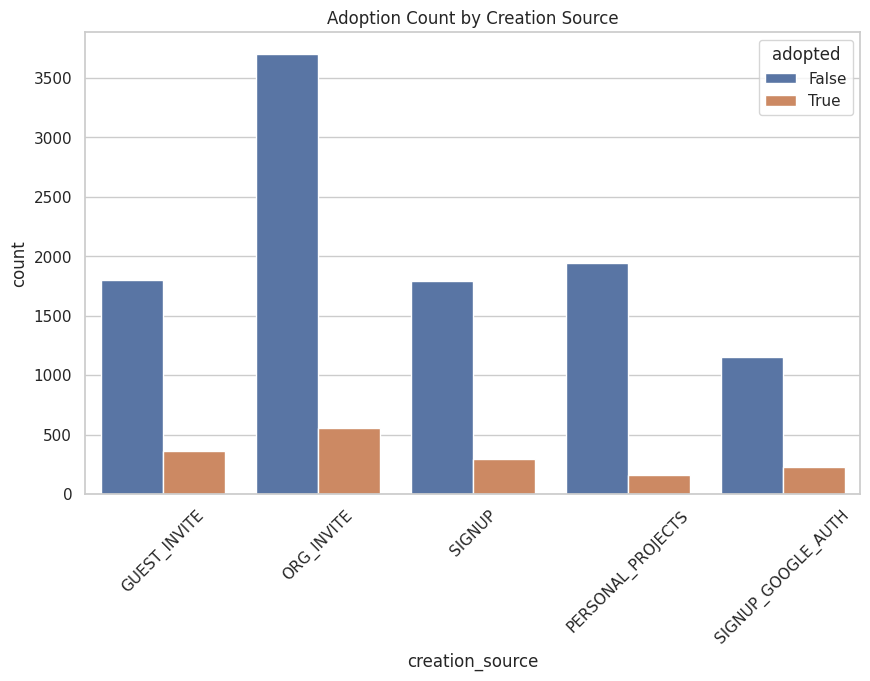

Adoption rates by source:
creation_source
SIGNUP_GOOGLE_AUTH    0.167509
GUEST_INVITE          0.166436
SIGNUP                0.140393
ORG_INVITE            0.129995
PERSONAL_PROJECTS     0.077688
Name: adopted, dtype: float64


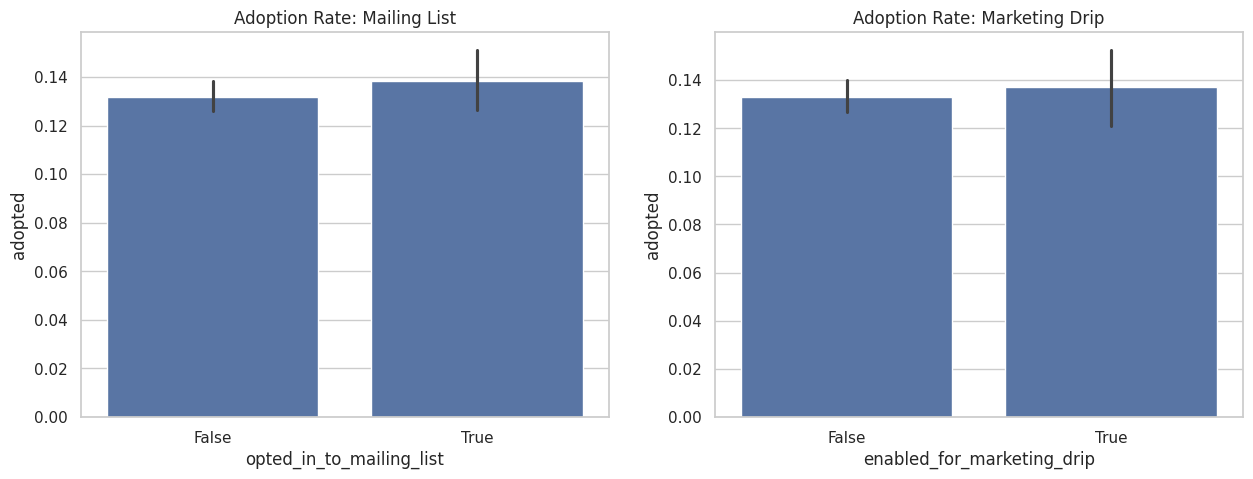

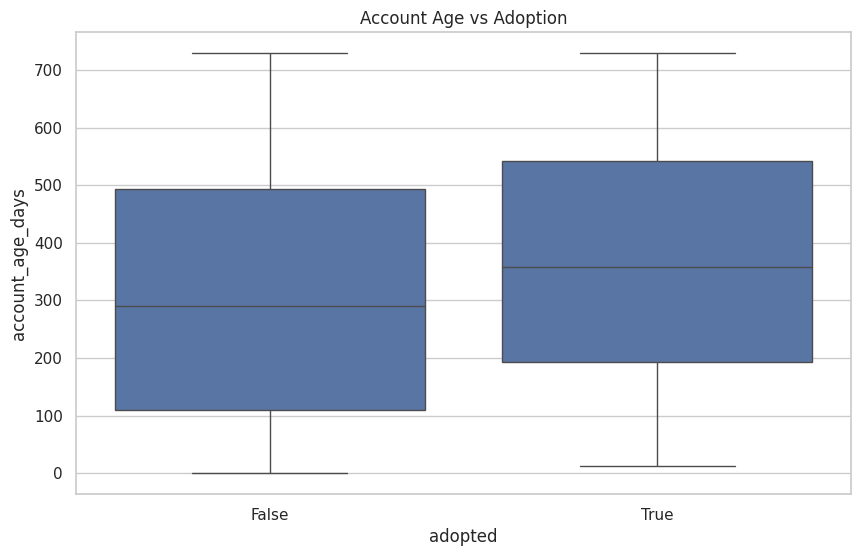

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style='whitegrid')

# 1. Adoption by Creation Source
plt.figure(figsize=(10, 6))
sns.countplot(data=df_users, x='creation_source', hue='adopted')
plt.title('Adoption Count by Creation Source')
plt.xticks(rotation=45)
plt.show()

# Calculate adoption rates by source
source_rates = df_users.groupby('creation_source')['adopted'].mean().sort_values(ascending=False)
print("Adoption rates by source:")
print(source_rates)

# 2. Adoption by Marketing and Mailing List
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=df_users, x='opted_in_to_mailing_list', y='adopted', ax=ax[0])
ax[0].set_title('Adoption Rate: Mailing List')
sns.barplot(data=df_users, x='enabled_for_marketing_drip', y='adopted', ax=ax[1])
ax[1].set_title('Adoption Rate: Marketing Drip')
plt.show()

# 3. Time-based analysis: Does account age correlate with adoption?
df_users['account_age_days'] = (df_users['creation_time'].max() - df_users['creation_time']).dt.days
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_users, x='adopted', y='account_age_days')
plt.title('Account Age vs Adoption')
plt.show()

The EDA shows that users who sign up via Google Auth or Guest Invites have higher adoption rates, while those invited to personal projects are the least likely to be adopted. Additionally, older accounts seem to have a higher likelihood of adoption.

In [10]:
cols_to_check = ['creation_source', 'opted_in_to_mailing_list', 'enabled_for_marketing_drip']

for col in cols_to_check:
    print(f"--- Cross-tabulation for {col} ---")
    # Count values
    ct = pd.crosstab(df_users[col], df_users['adopted'])
    # Normalized (percentages)
    ct_pct = pd.crosstab(df_users[col], df_users['adopted'], normalize='index')

    display(pd.concat([ct, ct_pct.rename(columns={False: 'False %', True: 'True %'})], axis=1))
    print("\n")

--- Cross-tabulation for creation_source ---


adopted,False,True,False %,True %
creation_source,,,,
GUEST_INVITE,1803,360,0.833564,0.166436
ORG_INVITE,3701,553,0.870005,0.129995
PERSONAL_PROJECTS,1947,164,0.922312,0.077688
SIGNUP,1794,293,0.859607,0.140393
SIGNUP_GOOGLE_AUTH,1153,232,0.832491,0.167509




--- Cross-tabulation for opted_in_to_mailing_list ---


adopted,False,True,False %,True %
opted_in_to_mailing_list,,,,
False,7818,1188,0.868088,0.131912
True,2580,414,0.861723,0.138277




--- Cross-tabulation for enabled_for_marketing_drip ---


adopted,False,True,False %,True %
enabled_for_marketing_drip,,,,
False,8852,1356,0.867163,0.132837
True,1546,246,0.862723,0.137277


The cross-tabulations confirm our earlier observations: users joining for personal projects are less likely to become 'adopted,' while those using Google Auth or guest invites show the highest engagement. Interestingly, being on the mailing list or marketing drip has almost no impact on the adoption rate (~13% for both groups).

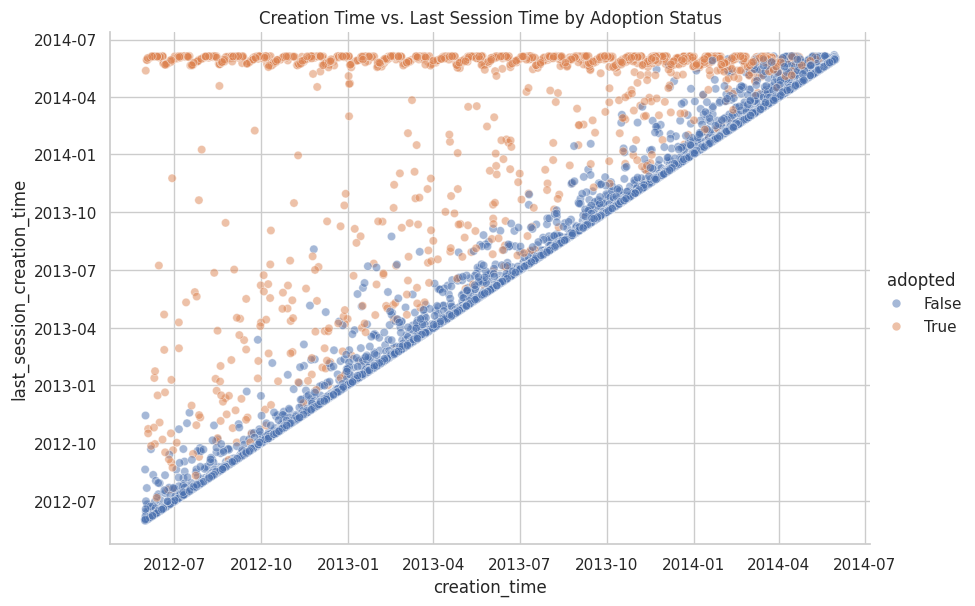

In [11]:
# Visualize relationship between creation and last session times
sns.relplot(
    data=df_users,
    x='creation_time',
    y='last_session_creation_time',
    hue='adopted',
    alpha=0.5,
    height=6,
    aspect=1.5
)
plt.title('Creation Time vs. Last Session Time by Adoption Status')
plt.show()

The relplot clearly shows that adopted users (in orange) are those whose last session was far from their creation date, often clustered at the top of the chart near the end of the data collection period.

Model Accuracy: 0.8642

Classification Report Summary Table:


,precision,recall,f1-score,support
False,0.867,0.997,0.927,2080.000
True,0.125,0.003,0.006,320.000
accuracy,0.864,0.864,0.864,0.864
macro avg,0.496,0.500,0.467,2400.000
weighted avg,0.768,0.864,0.804,2400.000


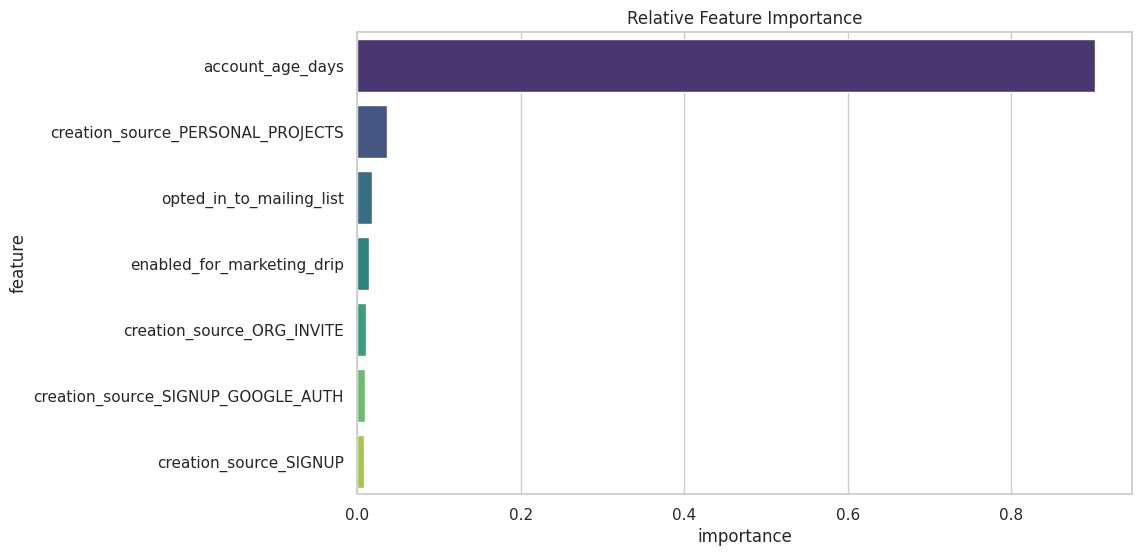

Detailed Feature Importance Scores:
                              feature  importance
2                    account_age_days    0.902653
4   creation_source_PERSONAL_PROJECTS    0.035922
0            opted_in_to_mailing_list    0.018199
1          enabled_for_marketing_drip    0.014307
3          creation_source_ORG_INVITE    0.011182
6  creation_source_SIGNUP_GOOGLE_AUTH    0.008898
5              creation_source_SIGNUP    0.008838


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modeling ---
# Prepare features
features = ['creation_source', 'opted_in_to_mailing_list', 'enabled_for_marketing_drip', 'account_age_days']
X = pd.get_dummies(df_users[features], columns=['creation_source'], drop_first=True)
y = df_users['adopted']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)

# --- Classification Report as DataFrame ---
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("Model Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report Summary Table:")
display(report_df.round(3))

# --- Feature Importance Visualization ---
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
plt.title('Relative Feature Importance')
plt.show()

print("Detailed Feature Importance Scores:")
print(feature_importance_df)

The analysis is complete. The Random Forest model identifies 'account_age_days' as the most significant factor (approx. 90% importance), which makes sense as users who joined earlier have had more time to establish the required login patterns. Among the other factors, users joining for 'PERSONAL_PROJECTS' showed a distinct (though smaller) influence on the model, aligning with our earlier observation that they have the lowest adoption rate. While the model has high overall accuracy (86%), its low recall for adopted users suggests that adoption is difficult to predict solely from sign-up metadata, implying that behavioral factors post-signup are likely more influential.